# SPY Exploration — Phase 1
15 years of SPY data: price and 20-day rolling volatility.

In [1]:
import sys
import os

# Add project root to path so `src` is importable
sys.path.insert(0, os.path.abspath(".."))

from src.data import load_data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = load_data("SPY", start="2011-01-01", end="2026-01-01")
print(df.shape)
df.head()

(3771, 4)


,close,daily_return,log_return,volatility
Date,,,,
2011-01-04,96.874771,-0.000551,-0.000551,NaN
2011-01-05,97.378288,0.005198,0.005184,NaN
2011-01-06,97.187592,-0.001958,-0.001960,NaN
2011-01-07,96.996826,-0.001963,-0.001965,NaN
2011-01-10,96.874771,-0.001258,-0.001259,NaN


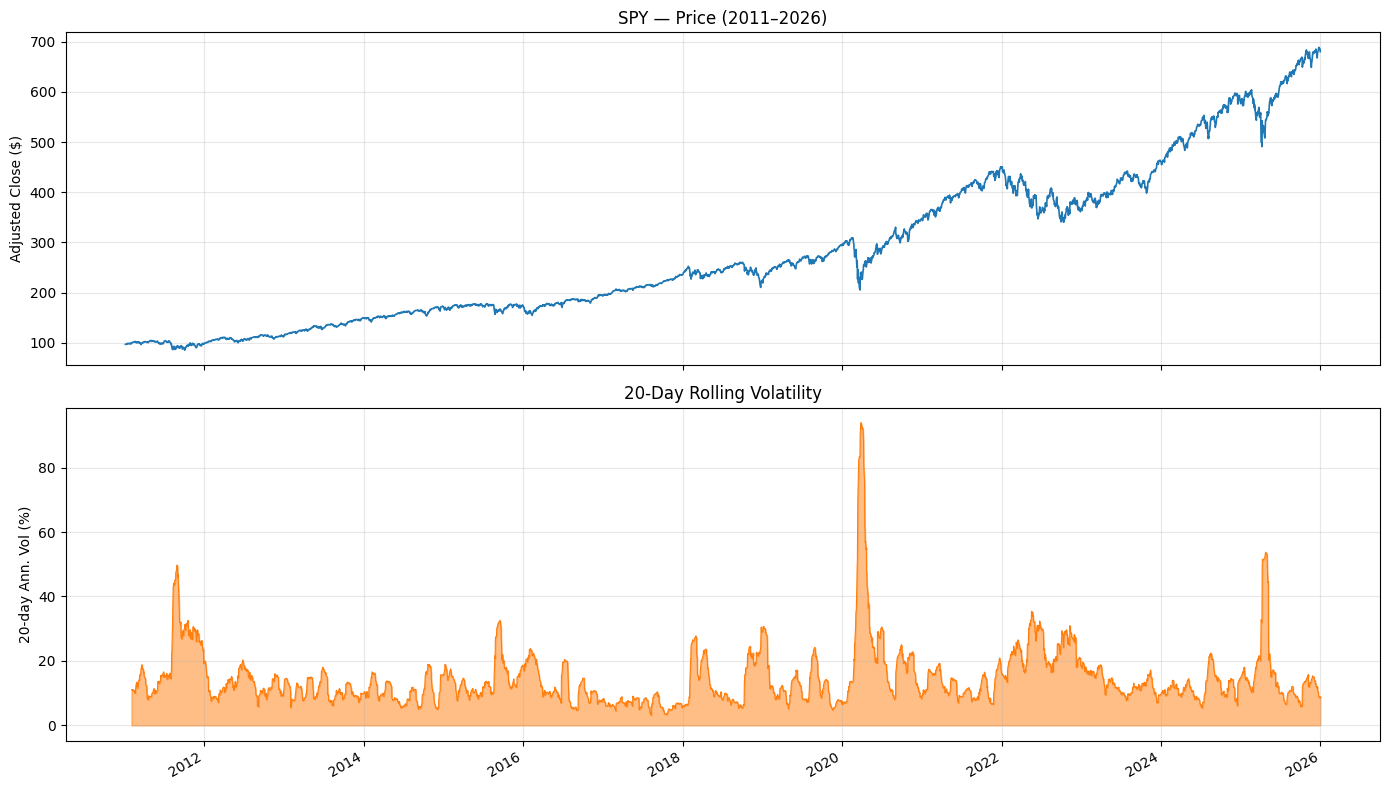

Saved spy_price_vol.png


In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Price ---
ax1.plot(df.index, df["close"], color="#1f77b4", linewidth=1.2)
ax1.set_ylabel("Adjusted Close ($)")
ax1.set_title("SPY — Price (2011–2026)")
ax1.grid(True, alpha=0.3)

# --- 20-day Rolling Volatility ---
ax2.fill_between(df.index, df["volatility"] * 100, alpha=0.5, color="#ff7f0e")
ax2.plot(df.index, df["volatility"] * 100, color="#ff7f0e", linewidth=0.8)
ax2.set_ylabel("20-day Ann. Vol (%)")
ax2.set_title("20-Day Rolling Volatility")
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig("spy_price_vol.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved spy_price_vol.png")

In [4]:
# Quick stats
print(df[["daily_return", "log_return", "volatility"]].describe().round(4))

       daily_return  log_return  volatility
count     3771.0000   3771.0000   3752.0000
mean         0.0006      0.0005      0.1460
std          0.0108      0.0108      0.0936
min         -0.1094     -0.1159      0.0319
25%         -0.0037     -0.0037      0.0912
50%          0.0007      0.0007      0.1210
75%          0.0058      0.0058      0.1713
max          0.1050      0.0999      0.9392
